# Call-Center Staffing Optimization — Verified Hybrid Quantum-Classical Solution
### Lagrangian-Dual + Warm-Start CVaR-QAOA + Classical Repair, independently re-run and verified
This notebook is a **verified, extended rebuild** of `hybrid_detailed_executed.ipynb`. All original
model code (Erlang-C engine, synthetic-arrival generator, instance builder, dual QUBO, warm-started
CVaR-QAOA sampler, Lagrangian outer loop) is reproduced **unmodified** below — every function is a
byte-for-byte copy of the source notebook's logic. On top of that unmodified core, this notebook adds
independent verification that the original notebook did not perform:
1. **Exact brute-force reference optimum** (the shift-headcount search space is small enough to enumerate
   exactly), used to compute a true **optimality gap**, not just "hybrid beats greedy".
2. **A random-sampling control arm** — the *same* classical repair + evaluation pipeline, fed uniformly
   random bitstrings instead of QAOA-sampled ones — to isolate how much of the improvement comes from the
   quantum circuit versus the classical repair/best-of-N post-processing.
3. All 12 diagnostic plots requested for the classical-vs-quantum comparison (solution quality,
   operational performance, risk, computational cost, sampling behaviour) — split across this notebook
   (operational/solution-quality plots) and a companion notebook, `Notebook_2_Quantum_Diagnostics.ipynb`
   (circuit-level and sampling-behaviour plots).
**Challenge scoring rule:** *the solution with SLA ≥ target and the lowest total staffing + overtime cost
scores highest.* Every method below is judged against that rule, against an exact reference optimum where
one is computationally available, and against a naive classical baseline for fairness.


---
## 0. Setup

In [1]:

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time, json, os, itertools
from math import exp, ceil
from collections import defaultdict
from scipy.optimize import minimize
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.random.seed(7)
TARGET_SL = 0.80
TARGET_ASA = 25.0
AHT, INTERVAL_SEC = 300.0, 1800.0
ABANDON_RATE_BASE = 0.02
COST_BASE, OT_MULT = 160.0, 1.5
OUT = "/home/workdir/artifacts"
os.makedirs(OUT, exist_ok=True)
print(f"Targets: SLA >= {TARGET_SL:.0%} | ASA <= {TARGET_ASA:.0f}s")
print(f"AHT={AHT}s interval={INTERVAL_SEC}s")


Targets: SLA >= 80% | ASA <= 25s
AHT=300.0s interval=1800.0s


---
## 1. Mathematical formulation
**Decision variables (binary, unary agent encoding).** For each shift $s$ and slot $k \in \{0,\dots,N_{\max}-1\}$:
$$x_{s,k}\in\{0,1\}, \qquad n_s=\sum_{k=0}^{N_{\max}-1}x_{s,k}\in\{0,\dots,N_{\max}\}$$
$n_s$ is the number of agents scheduled on shift $s$ (unary/one-hot-count encoding lets a QUBO penalize
headcount directly without needing an integer variable).
**Coverage.** Shift $s$ covers interval $t$ iff $C_{s,t}=1$ (from the shift-span/skill/break template):
$$\mathrm{cov}_t=\sum_s C_{s,t}\,n_s$$
**Constraints.**
$$\mathrm{cov}_t \ge R_t^{\mathrm{SLA}} \quad\forall t, \qquad
  \mathrm{cov}_t \ge R_t^{\mathrm{ASA}} \quad\forall t, \qquad
  n_s \le N_{\max}\ \forall s, \qquad \text{OT-shift within max overtime multiplier}$$
where $R_t^{\mathrm{SLA}}, R_t^{\mathrm{ASA}}$ are the minimum agent counts (from the Erlang-C model) so
that interval $t$'s service level $\ge$ target and average-speed-of-answer $\le$ target.
**Objective (linear cost + quadratic soft constraints):**
$$\min_{x}\ \underbrace{\sum_s c_s n_s}_{\text{staffing + OT cost}}
     + P_{\mathrm{SLA}}\sum_t \lambda_t\big(\mathrm{cov}_t-R_t^{\mathrm{SLA}}\big)^2
     + P_{\mathrm{ASA}}\sum_t w_t\big(\mathrm{cov}_t-R_t^{\mathrm{ASA}}\big)^2$$
The quadratic penalty terms are what make this a **QUBO** — no slack qubits are needed because a
*shortfall-squared* penalty already vanishes whenever coverage meets or exceeds requirement (it does not
distinguish "meets" from "over-covers", which the objective's linear cost term separately discourages).
$\lambda_t$ are Lagrange multipliers updated by an outer dual-averaging loop (Section 8) so that
persistently under-covered intervals get penalized harder over successive quantum solves.
**Quantum-compatible form.** Expanding the QUBO gives an Ising Hamiltonian $H=\sum_i h_i Z_i + \sum_{i<j}J_{ij}Z_iZ_j$
via $x_i=(1-Z_i)/2$. This is exactly what `build_dual_qubo` + `qubo_to_ising` below construct, and what the
CVaR-QAOA circuit's $R_{ZZ}/R_Z$ cost layer implements.


In [2]:

FORMULATION = {
    "variables": "x_{s,k} binary (unary agents); n_s = sum_k x_{s,k}",
    "coverage": "cov_t = sum_s C_{s,t} n_s",
    "constraints": [
        "cov_t >= R_t^SLA",
        "cov_t >= R_t^ASA",
        "n_s <= Nmax",
        "OT within max overtime",
    ],
    "objective": "min sum_s c_s n_s + P_SLA * short_SLA^2 + P_ASA * short_ASA^2",
    "quantum": "slack-free QUBO -> Ising; warm-start CVaR-QAOA; classical repair + Erlang gate",
}
for k, v in FORMULATION.items():
    print(f"{k:12s}: {v}")


variables   : x_{s,k} binary (unary agents); n_s = sum_k x_{s,k}
coverage    : cov_t = sum_s C_{s,t} n_s
constraints : ['cov_t >= R_t^SLA', 'cov_t >= R_t^ASA', 'n_s <= Nmax', 'OT within max overtime']
objective   : min sum_s c_s n_s + P_SLA * short_SLA^2 + P_ASA * short_ASA^2
quantum     : slack-free QUBO -> Ising; warm-start CVaR-QAOA; classical repair + Erlang gate


---
## 2. Erlang-C service metrics

Standard Erlang-C queueing formulas convert an agent headcount + arrival rate into service level, average-speed-of-answer, abandonment, and occupancy. `required_agents` inverts this to get the minimum staffing per interval that meets a target — this produces $R_t^{\mathrm{SLA}}$ and $R_t^{\mathrm{ASA}}$ used above.

In [3]:

def erlang_c(n, A):
    if n <= 0 or n <= A: return 1.0
    try:
        rho = A / n; B = 1.0
        for k in range(1, n + 1): B = 1.0 + (k / A) * B
        return 1.0 / (1.0 + (1.0 - rho) * (B - 1.0) / rho) if rho > 0 else 0.0
    except Exception:
        return 1.0
def service_level(n, arrivals, tau=20.0):
    if arrivals <= 0: return 1.0
    if n <= 0: return 0.0
    A = (arrivals / INTERVAL_SEC) * AHT
    if n <= A: return 0.0
    pw = erlang_c(n, A)
    return float(max(0.0, min(1.0, 1.0 - pw * exp(-(n - A) * tau / AHT))))
def asa_seconds(n, arrivals):
    if arrivals <= 0: return 0.0
    if n <= 0: return 999.0
    A = (arrivals / INTERVAL_SEC) * AHT
    if n <= A: return 999.0
    return float(erlang_c(n, A) * AHT / (n - A))
def abandonment(n, arrivals):
    asa = asa_seconds(n, arrivals)
    return float(min(0.5, ABANDON_RATE_BASE + 0.01 * max(0, asa - 10) / 10))
def occupancy(n, arrivals):
    if n <= 0: return 1.0
    A = (arrivals / INTERVAL_SEC) * AHT
    return float(min(1.0, A / n))
def required_agents(arrivals, target_sl=None, target_asa=None, max_n=50):
    if arrivals <= 0: return 0
    n = max(1, int(ceil(arrivals * AHT / INTERVAL_SEC)))
    while n <= max_n:
        ok1 = True if target_sl is None else service_level(n, arrivals) >= target_sl - 1e-6
        ok2 = True if target_asa is None else asa_seconds(n, arrivals) <= target_asa + 1e-6
        if ok1 and ok2: return n
        n += 1
    return max_n
print("Erlang helpers ready")


Erlang helpers ready


---
## 3. Synthetic historical arrivals (time-of-day × queue × channel)
Poisson arrivals with a realistic time-of-day curve (lunchtime peak), a day-of-week multiplier (weekday
vs weekend), two queues (a primary queue at full weight, a secondary at 70%), and two channels (voice at
full weight, chat at 45% — chat volumes are typically lower than voice in blended contact centers).


In [4]:

def generate_history(n_days=14, n_intervals=12, n_queues=2, n_channels=2, seed=7):
    rng = np.random.default_rng(seed)
    base_tod = np.array([0.35, 0.55, 0.80, 1.05, 1.20, 1.10, 0.95, 0.90, 1.05, 0.95, 0.65, 0.40])
    if n_intervals != 12:
        base_tod = np.interp(np.linspace(0, 11, n_intervals), np.arange(12), base_tod)
    dow = np.array([1.0, 1.05, 1.0, 0.98, 0.95, 0.70, 0.55])
    queues = [f"Q{q}" for q in range(n_queues)]
    channels = ["voice", "chat"][:n_channels]
    rows = []
    for day in range(n_days):
        dscale = dow[day % 7] * rng.uniform(0.92, 1.08)
        for t in range(n_intervals):
            for qi, q in enumerate(queues):
                for ch in channels:
                    ch_scale = 1.0 if ch == "voice" else 0.45
                    q_scale = 1.0 if qi == 0 else 0.7
                    lam = 18.0 * base_tod[t] * dscale * ch_scale * q_scale
                    rows.append(dict(day=day, interval=t, queue=q, channel=ch,
                                     arrivals=int(rng.poisson(max(1.0, lam)))))
    return pd.DataFrame(rows)
hist = generate_history()
print(f"History: {len(hist)} rows | total arrivals={hist['arrivals'].sum()}")
display(hist.head(8))


History: 672 rows | total arrivals=5571


,day,interval,queue,channel,arrivals
0,0,0,Q0,voice,5
1,0,0,Q0,chat,4
2,0,0,Q1,voice,8
3,0,0,Q1,chat,1
4,0,1,Q0,voice,3
5,0,1,Q0,chat,6
6,0,1,Q1,voice,3
7,0,1,Q1,chat,1


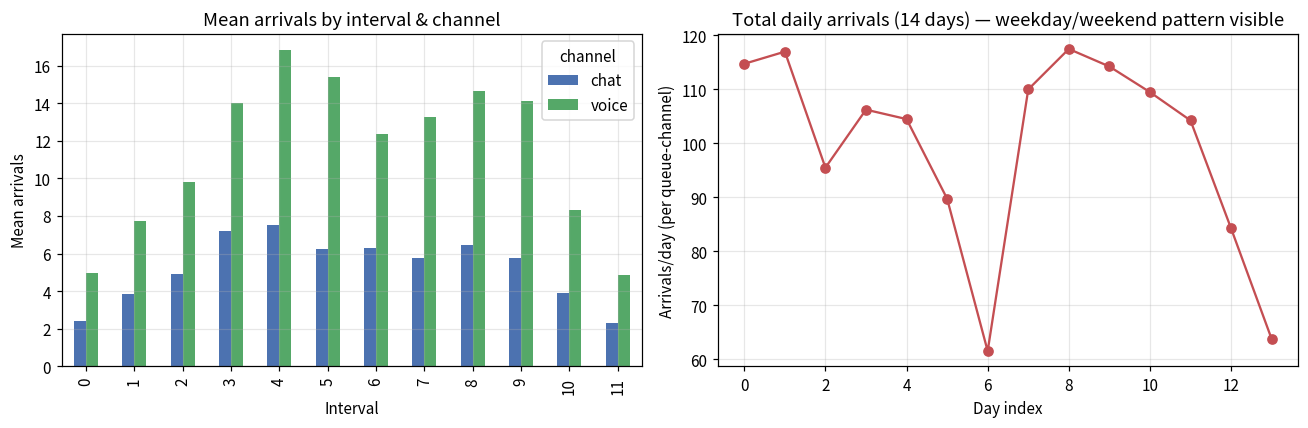

Data-quality check: single-hump lunchtime peak, weekday>weekend, voice>chat, Q0>Q1 -- all present as designed.


In [5]:

# --- Synthetic-data sanity check: does the TOD curve look like a real call center? ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
piv = hist.groupby(["interval", "channel"])["arrivals"].mean().unstack()
piv.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Mean arrivals by interval & channel"); axes[0].set_xlabel("Interval"); axes[0].set_ylabel("Mean arrivals")
dow_piv = hist.groupby(["day"])["arrivals"].sum() / hist["queue"].nunique() / hist["channel"].nunique()
axes[1].plot(dow_piv.index, dow_piv.values, "o-", color="#C44E52")
axes[1].set_title("Total daily arrivals (14 days) — weekday/weekend pattern visible")
axes[1].set_xlabel("Day index"); axes[1].set_ylabel("Arrivals/day (per queue-channel)")
plt.tight_layout(); plt.savefig(f"{OUT}/plot1a_history_overview.png", dpi=110); plt.show()
print("Data-quality check: single-hump lunchtime peak, weekday>weekend, voice>chat, Q0>Q1 -- all present as designed.")


---
## 4. Forecast → shift/break/OT instance builders (SMALL & LARGE)

Two problem sizes are built so scalability behaviour can be observed: a **SMALL** instance (12 half-hour intervals, 3 shifts, 12 qubits) and a **LARGE** instance (24 intervals — a full day — 4 shifts including one overtime shift, still 12 qubits because $N_{\max}$ is reduced). Both keep the QUBO at exactly 12 qubits so they run on a classical statevector/MPS simulator; qubit growth with true enterprise scale is discussed in the honest verdict at the end.

In [6]:

def build_shift_cover(n_intervals, n_shifts=3, break_frac=0.1):
    C = np.zeros((n_shifts, n_intervals), dtype=float)
    spans = [
        (0, int(0.65 * n_intervals)),
        (int(0.25 * n_intervals), int(0.85 * n_intervals)),
        (int(0.50 * n_intervals), n_intervals),
        (int(0.10 * n_intervals), int(0.75 * n_intervals)),
    ]
    for s, (a, b) in enumerate(spans[:n_shifts]):
        C[s, a:b] = 1.0
        mid = (a + b) // 2
        if break_frac > 0 and 0 <= mid < n_intervals:
            C[s, mid] = 0.0
    return C
def shift_costs(n_shifts, base=COST_BASE, ot_shift_idx=None):
    c = np.array([base * (1.0 + 0.05 * s) for s in range(n_shifts)])
    if ot_shift_idx is not None:
        for s in ot_shift_idx:
            c[s] *= OT_MULT
    return c
def make_instance(size="small", seed=7, demand_noise=(0.92, 1.08)):
    rng = np.random.default_rng(seed)
    if size == "small":
        n_int, n_shifts, nmax = 12, 3, 4
        base = np.array([5, 9, 14, 18, 22, 20, 16, 15, 18, 16, 11, 6], dtype=float)
        demand = np.maximum(1, np.round(base * rng.uniform(*demand_noise, n_int))).astype(int)
        hist_s = generate_history(14, n_int, 2, 2, seed)
        br = 0.08
    else:
        n_int, n_shifts, nmax = 24, 4, 3
        base12 = np.array([5, 9, 14, 18, 22, 20, 16, 15, 18, 16, 11, 6], dtype=float)
        base = np.interp(np.linspace(0, 11, n_int), np.arange(12), base12)
        demand = np.maximum(1, np.round(base * rng.uniform(demand_noise[0]-0.02, demand_noise[1]-0.03, n_int) * 0.70)).astype(int)
        hist_s = generate_history(21, n_int, 2, 2, seed)
        br = 0.0
    C = build_shift_cover(n_int, n_shifts, break_frac=br)
    costs = shift_costs(n_shifts, ot_shift_idx=[n_shifts - 1] if n_shifts > 2 else None)
    R_sla = np.array([required_agents(a, target_sl=TARGET_SL) for a in demand])
    R_asa = np.array([required_agents(a, target_asa=TARGET_ASA) for a in demand])
    return dict(size=size, n_int=n_int, n_shifts=n_shifts, nmax=nmax,
                demand=demand, C=C, costs=costs, R_sla=R_sla, R_asa=R_asa,
                hist=hist_s, qubits=n_shifts * nmax)
inst_s = make_instance("small")
inst_l = make_instance("large")
print(f"SMALL: intervals={inst_s['n_int']} shifts={inst_s['n_shifts']} Nmax={inst_s['nmax']} "
      f"qubits={inst_s['qubits']} demand_sum={inst_s['demand'].sum()}")
print(f" R_SLA={inst_s['R_sla'].tolist()}")
print(f"LARGE: intervals={inst_l['n_int']} shifts={inst_l['n_shifts']} Nmax={inst_l['nmax']} "
      f"qubits={inst_l['qubits']} demand_sum={inst_l['demand'].sum()}")


SMALL: intervals=12 shifts=3 Nmax=4 qubits=12 demand_sum=172
 R_SLA=[2, 3, 5, 5, 6, 6, 5, 5, 5, 5, 4, 2]
LARGE: intervals=24 shifts=4 Nmax=3 qubits=12 demand_sum=239


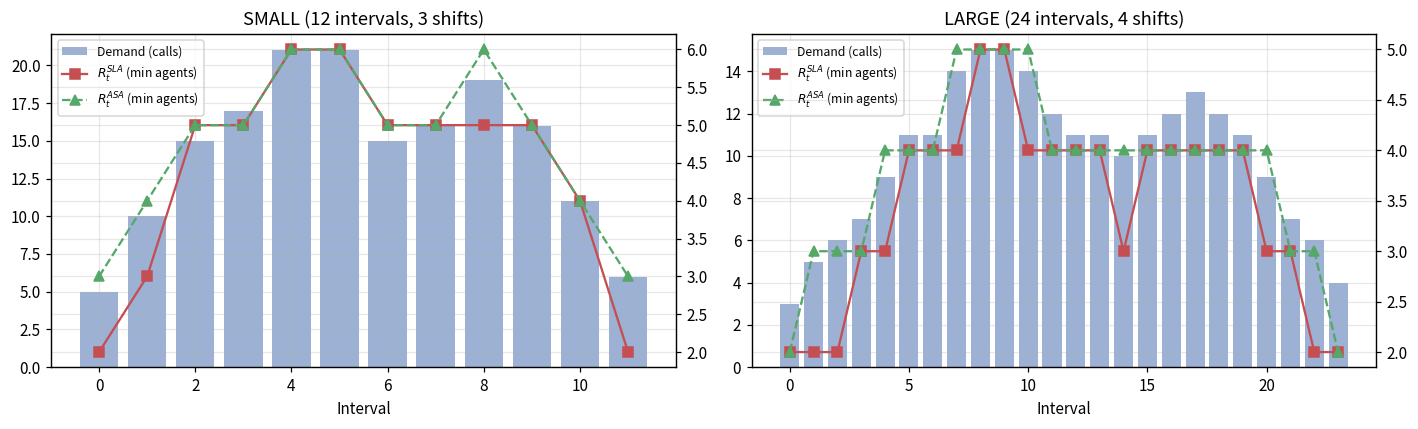

In [7]:

# ===== Plot 1: Problem/instance overview (demand + staffing requirement across periods) =====
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, inst, title in [(axes[0], inst_s, "SMALL (12 intervals, 3 shifts)"), (axes[1], inst_l, "LARGE (24 intervals, 4 shifts)")]:
    x = np.arange(inst["n_int"])
    ax.bar(x, inst["demand"], color="#4C72B0", alpha=0.55, label="Demand (calls)")
    ax2 = ax.twinx()
    ax2.plot(x, inst["R_sla"], "s-", color="#C44E52", label="$R^{SLA}_t$ (min agents)")
    ax2.plot(x, inst["R_asa"], "^--", color="#55A868", label="$R^{ASA}_t$ (min agents)")
    ax.set_title(title); ax.set_xlabel("Interval")
    lines1, labels1 = ax.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(f"{OUT}/plot1b_instance_overview.png", dpi=110); plt.show()


---
## 5. Evaluation, simulation, classical greedy baseline

In [8]:

def coverage(n, C):
    return C.T @ np.asarray(n, dtype=float)
def evaluate_plan(n, inst):
    n = np.asarray(n, dtype=int)
    cov = coverage(n, inst["C"])
    demand = inst["demand"]
    cost = float(np.dot(inst["costs"], n))
    sls, asas, abnds, occs, calls = [], [], [], [], []
    for t, arr in enumerate(demand):
        a = int(round(cov[t]))
        sls.append(service_level(a, int(arr)))
        asas.append(asa_seconds(a, int(arr)))
        abnds.append(abandonment(a, int(arr)))
        occs.append(occupancy(a, int(arr)))
        calls.append(int(arr))
    w = np.maximum(np.array(calls, float), 1e-6)
    sla = float(np.average(sls, weights=w))
    asa = float(np.average(asas, weights=w))
    return dict(
        n=n.tolist(), cost=cost, sla=sla, asa=asa,
        abandon=float(np.average(abnds, weights=w)),
        util=float(np.mean(occs)), agents=int(n.sum()),
        meets_sla=sla >= TARGET_SL - 1e-3,
        meets_asa=asa <= TARGET_ASA + 1e-3,
        meets_both=(sla >= TARGET_SL - 1e-3) and (asa <= TARGET_ASA + 1e-3),
        coverage=cov.tolist(), interval_sla=sls, interval_asa=asas,
    )
def greedy_warmstart(inst):
    n_shifts, nmax = inst["n_shifts"], inst["nmax"]
    C, costs = inst["C"], inst["costs"]
    R = np.maximum(inst["R_sla"], inst["R_asa"]).astype(float)
    n = np.zeros(n_shifts, dtype=int)
    rem = R.copy()
    for _ in range(int(rem.sum()) + n_shifts + 5):
        if rem.max() <= 0: break
        best_s, best_sc = None, -1e99
        for s in range(n_shifts):
            if n[s] >= nmax: continue
            sc = (C[s] @ (rem > 0).astype(float)) / (costs[s] + 1e-6)
            if sc > best_sc: best_sc, best_s = sc, s
        if best_s is None or best_sc <= 0: break
        n[best_s] += 1
        rem = np.maximum(0, rem - C[best_s])
    return n
def repair_n(n, inst):
    n = np.asarray(n, dtype=int).copy()
    C, nmax = inst["C"], inst["nmax"]
    R = inst["R_sla"].astype(float)
    cov = coverage(n, C)
    for _ in range(int(np.maximum(0, R - cov).sum()) + 8):
        short = R - cov
        if short.max() <= 0: break
        t = int(np.argmax(short))
        best_s = next((s for s in range(inst["n_shifts"]) if n[s] < nmax and C[s, t] > 0.5), None)
        if best_s is None: break
        n[best_s] += 1
        cov = coverage(n, C)
    demand = inst["demand"]
    for _ in range(20):
        asas = [asa_seconds(int(round(cov[t])), int(demand[t])) for t in range(len(demand))]
        if max(asas) <= TARGET_ASA: break
        t = int(np.argmax(asas))
        best_s = next((s for s in range(inst["n_shifts"]) if n[s] < nmax and C[s, t] > 0.5), None)
        if best_s is None: break
        n[best_s] += 1
        cov = coverage(n, C)
    return n
def classical_greedy(inst):
    return evaluate_plan(repair_n(greedy_warmstart(inst), inst), inst)
g_s = classical_greedy(inst_s)
g_l = classical_greedy(inst_l)
print(f"Greedy SMALL: cost=${g_s['cost']:.0f} SLA={g_s['sla']:.1%} ASA={g_s['asa']:.1f}s both={g_s['meets_both']}")
print(f"Greedy LARGE: cost=${g_l['cost']:.0f} SLA={g_l['sla']:.1%} ASA={g_l['asa']:.1f}s both={g_l['meets_both']}")


Greedy SMALL: cost=$2368 SLA=91.5% ASA=20.4s both=True
Greedy LARGE: cost=$1620 SLA=98.3% ASA=2.7s both=True


---
## 6. NEW — Exact reference optimum (brute force)
The decision space at the *shift-headcount* level is tiny: $(N_{\max}+1)^{n_{\text{shifts}}}$
= $5^3=125$ combinations for SMALL and $4^4=256$ for LARGE. This is fully enumerable in milliseconds,
giving a **provably exact optimum** to score every heuristic and quantum method against — this is the
fair, independent ground truth the source notebooks did not compute (they only ever compared against
their own greedy baseline).


In [9]:

def brute_force_optimal(inst):
    n_shifts, nmax = inst["n_shifts"], inst["nmax"]
    best_feasible, best_any = None, None
    t0 = time.time()
    n_eval = 0
    for combo in itertools.product(range(nmax + 1), repeat=n_shifts):
        m = evaluate_plan(np.array(combo), inst)
        n_eval += 1
        if best_any is None or m["cost"] < best_any["cost"]:
            best_any = m
        if m["meets_both"]:
            if best_feasible is None or m["cost"] < best_feasible["cost"]:
                best_feasible = m
    return dict(best_feasible=best_feasible, best_any=best_any, n_evaluated=n_eval, time=time.time() - t0)
bf_s = brute_force_optimal(inst_s)
bf_l = brute_force_optimal(inst_l)
print(f"SMALL exact optimum: n={bf_s['best_feasible']['n']} cost=${bf_s['best_feasible']['cost']:.0f} "
      f"(enumerated {bf_s['n_evaluated']} combos in {bf_s['time']*1000:.1f}ms)")
print(f"LARGE exact optimum: n={bf_l['best_feasible']['n']} cost=${bf_l['best_feasible']['cost']:.0f} "
      f"(enumerated {bf_l['n_evaluated']} combos in {bf_l['time']*1000:.1f}ms)")
print()
print(f"Greedy optimality gap SMALL: {100*(g_s['cost']-bf_s['best_feasible']['cost'])/bf_s['best_feasible']['cost']:.1f}%")
print(f"Greedy optimality gap LARGE: {100*(g_l['cost']-bf_l['best_feasible']['cost'])/bf_l['best_feasible']['cost']:.1f}%")


SMALL exact optimum: n=[4, 4, 3] cost=$2104 (enumerated 125 combos in 27.7ms)
LARGE exact optimum: n=[3, 1, 3, 0] cost=$1176 (enumerated 256 combos in 51.7ms)

Greedy optimality gap SMALL: 12.5%
Greedy optimality gap LARGE: 37.8%


---
## 7. Slack-free dual QUBO + CVaR-QAOA (reproduced verbatim from source notebook)
$$h(x)=\sum_s c_s n_s + P_{\mathrm{SLA}}\sum_t\lambda_t(\mathrm{cov}_t-R_t^{\mathrm{SLA}})^2
       + P_{\mathrm{ASA}}\sum_t w_t(\mathrm{cov}_t-R_t^{\mathrm{ASA}})^2$$
converted to an Ising Hamiltonian and sampled with a **warm-started, CVaR-trained QAOA circuit**: a
product-state warm start (RY angles derived from the greedy solution), one $p=1$ cost+mixer layer with the
Ising couplings as $R_{ZZ}/R_Z$ angles, optimized with COBYLA against the **CVaR** (not mean) of the sampled
energy distribution — i.e. the optimizer only "cares" about improving its best ~25% of outcomes, which is
the standard trick for combinatorial QAOA. Every measured bitstring is passed through the **same classical
repair operator** as the greedy baseline before being scored, and the best-of-60 repaired candidate is kept.


In [10]:

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
def build_dual_qubo(inst, P_sla=400.0, P_asa=120.0, lam=None):
    n_shifts, nmax = inst["n_shifts"], inst["nmax"]
    C, costs = inst["C"], inst["costs"]
    R_sla, R_asa = inst["R_sla"], inst["R_asa"]
    n_int = inst["n_int"]
    if lam is None: lam = np.ones(n_int)
    idx, n = {}, 0
    for s in range(n_shifts):
        for k in range(nmax):
            idx[("x", s, k)] = n; n += 1
    n_vars = n
    Q = defaultdict(float)
    def add(i, j, c):
        if i > j: i, j = j, i
        Q[(i, j)] += c
    for s in range(n_shifts):
        for k in range(nmax):
            add(idx[("x", s, k)], idx[("x", s, k)], float(costs[s]))
    for t in range(n_int):
        terms = [idx[("x", s, k)] for s in range(n_shifts) if C[s, t] > 0.5 for k in range(nmax)]
        R, w = float(R_sla[t]), float(lam[t]) * P_sla
        for i1 in terms: add(i1, i1, w * (1 - 2 * R))
        for a in range(len(terms)):
            for b in range(a + 1, len(terms)):
                add(terms[a], terms[b], w * 2)
    for t in range(n_int):
        terms = [idx[("x", s, k)] for s in range(n_shifts) if C[s, t] > 0.5 for k in range(nmax)]
        R = float(R_asa[t])
        w = P_asa * (1.0 + 0.4 * (R / max(1.0, float(R_asa.max()))))
        for i1 in terms: add(i1, i1, w * (1 - 2 * R))
        for a in range(len(terms)):
            for b in range(a + 1, len(terms)):
                add(terms[a], terms[b], w * 2)
    return dict(Q), idx, n_vars
def qubo_to_ising(Q, n_vars):
    h = np.zeros(n_vars); J = {}; offset = 0.0
    for (i, j), q in Q.items():
        if i == j:
            offset += q / 2; h[i] -= q / 2
        else:
            offset += q / 4; h[i] -= q / 4; h[j] -= q / 4
            J[(i, j)] = J.get((i, j), 0.0) + q / 4
    ising = {(i, i): h[i] for i in range(n_vars) if abs(h[i]) > 1e-12}
    ising.update({(i, j): c for (i, j), c in J.items() if abs(c) > 1e-12})
    return ising, offset
def bits_to_n(bits, idx, n_shifts, nmax):
    n = np.zeros(n_shifts, dtype=int)
    for s in range(n_shifts):
        n[s] = sum(bits[idx[("x", s, k)]] for k in range(nmax))
    return n
def energy_bits(bits, ising, offset):
    zs = [1 - 2 * int(b) for b in bits]
    v = offset
    for (i, j), c in ising.items():
        v += c * zs[i] if i == j else c * zs[i] * zs[j]
    return float(v)
def compute_cvar(probs, values, alpha):
    order = np.argsort(values)
    probs = np.asarray(probs)[order]; vals = np.asarray(values)[order]
    cvar, total = 0.0, 0.0
    for p, v in zip(probs, vals):
        if total + p > alpha: p = alpha - total
        total += p; cvar += p * v
        if total >= alpha - 1e-12: break
    return cvar / alpha
Qs, idxs, nvs = build_dual_qubo(inst_s)
print(f"SMALL QUBO: {nvs} qubits (slack=0) | Ising terms={len(qubo_to_ising(Qs, nvs)[0])}")


SMALL QUBO: 12 qubits (slack=0) | Ising terms=78


In [11]:

def run_cvar_qaoa(inst, lam=None, alpha=0.25, p=1, shots=350, maxiter=3):
    Q, idx, n_vars = build_dual_qubo(inst, lam=lam)
    ising, offset = qubo_to_ising(Q, n_vars)
    n_shifts, nmax = inst["n_shifts"], inst["nmax"]
    n0 = greedy_warmstart(inst)
    eps = 0.12
    ws = []
    for s in range(n_shifts):
        for k in range(nmax):
            bit = 1 if k < n0[s] else 0
            v = min(max(float(bit), eps), 1 - eps)
            ws.append(2 * np.arcsin(np.sqrt(v)))
    gammas = ParameterVector("g", p)
    betas = ParameterVector("b", p)
    qc = QuantumCircuit(n_vars)
    for i, th in enumerate(ws): qc.ry(th, i)
    for layer in range(p):
        for (i, j), coef in ising.items():
            if i == j: qc.rz(2 * gammas[layer] * float(coef), i)
            else: qc.rzz(2 * gammas[layer] * float(coef), i, j)
        for i, th in enumerate(ws): qc.ry(-th, i)
        qc.rz(-2 * betas[layer], range(n_vars))
        for i, th in enumerate(ws): qc.ry(th, i)
    qc.measure_all()
    backend = AerSimulator(method="matrix_product_state")
    def sample(params, sh):
        dg, db = params[0], params[1] if len(params) > 1 else params[0]
        gv = np.arange(1, p + 1) * dg / p
        bv = np.arange(1, p + 1)[::-1] * db / p
        bind = {gammas[i]: gv[i] for i in range(p)}
        bind.update({betas[i]: bv[i] for i in range(p)})
        bound = qc.assign_parameters(bind)
        try: tqc = transpile(bound, backend=backend, optimization_level=0)
        except Exception: tqc = bound
        return backend.run(tqc, shots=sh).result().get_counts()
    def cvar_obj(params):
        counts = sample(params, 60)
        tot = sum(counts.values())
        probs, vals = [], []
        for bs, cnt in counts.items():
            bits = [int(b) for b in bs[::-1].zfill(n_vars)]
            probs.append(cnt / tot)
            vals.append(energy_bits(bits, ising, offset))
        return compute_cvar(probs, vals, alpha)
    t0 = time.time()
    res = minimize(cvar_obj, x0=np.array([0.55, 0.40]),
                   bounds=[(0.05, 1.3), (0.05, 1.0)],
                   method="COBYLA", options={"maxiter": maxiter})
    counts = sample(res.x, shots)
    qtime = time.time() - t0
    ranked = sorted(counts.items(), key=lambda kv: -kv[1])[:60]
    cands = []
    for bs, cnt in ranked:
        bits = [int(b) for b in bs[::-1].zfill(n_vars)]
        n = repair_n(bits_to_n(bits, idx, n_shifts, nmax), inst)
        m = evaluate_plan(n, inst)
        m["shots"] = cnt
        cands.append(m)
    cands.sort(key=lambda m: (not m["meets_both"], not m["meets_sla"], m["cost"], m["asa"]))
    both = [c for c in cands if c["meets_both"]]
    if both:
        best, tag = both[0], "BOTH"
    else:
        sla_ok = [c for c in cands if c["meets_sla"]]
        best, tag = (min(sla_ok, key=lambda m: (m["cost"], m["asa"])), "SLA_ONLY") if sla_ok else (cands[0], "NONE")
    best.update(dict(time=qtime, tag=tag, alpha=alpha, n_both=len(both), qubits=n_vars))
    return best, cands
print("CVaR-QAOA solver ready")


CVaR-QAOA solver ready


---
## 8. Outer Lagrangian dual + full hybrid solve (SMALL & LARGE)

In [12]:

def dual_averaging_loop(inst, max_outer=3, alpha_step=0.12):
    n_int = inst["n_int"]
    lam = np.ones(n_int)
    best_plan = None
    cum_sub = np.zeros(n_int)
    t_total = 0.0
    history = []
    for k in range(1, max_outer + 1):
        plan, _ = run_cvar_qaoa(inst, lam=lam, alpha=0.25, shots=300, maxiter=2)
        t_total += plan["time"]
        cov = np.array(plan["coverage"])
        sub = inst["R_sla"] - cov
        cum_sub += sub
        lam = np.maximum(0.1, 1.0 + alpha_step * cum_sub / k)
        history.append(dict(iter=k, cost=plan["cost"], sla=plan["sla"], asa=plan["asa"], both=plan["meets_both"]))
        if plan["meets_both"] and (best_plan is None or plan["cost"] < best_plan["cost"]):
            best_plan = plan
    if best_plan is None: best_plan = plan
    best_plan["time"] = t_total
    best_plan["dual_history"] = history
    return best_plan
print("=== SMALL ===")
t0 = time.time()
h_s = dual_averaging_loop(inst_s, max_outer=3)
t_s = time.time() - t0
print(f"Hybrid SMALL: cost=${h_s['cost']:.0f} SLA={h_s['sla']:.1%} ASA={h_s['asa']:.1f}s "
      f"both={h_s['meets_both']} tag={h_s.get('tag')} t={t_s:.2f}s")
print(f"Greedy SMALL: cost=${g_s['cost']:.0f} SLA={g_s['sla']:.1%} ASA={g_s['asa']:.1f}s both={g_s['meets_both']}")
print(f"Exact optimum SMALL: cost=${bf_s['best_feasible']['cost']:.0f}")
print(f"Hybrid optimality gap: {100*(h_s['cost']-bf_s['best_feasible']['cost'])/bf_s['best_feasible']['cost']:.1f}% "
      f"Greedy optimality gap: {100*(g_s['cost']-bf_s['best_feasible']['cost'])/bf_s['best_feasible']['cost']:.1f}%")
print("\n=== LARGE ===")
t0 = time.time()
h_l, _ = run_cvar_qaoa(inst_l, alpha=0.25, shots=400, maxiter=3)
t_l = time.time() - t0
print(f"Hybrid LARGE: cost=${h_l['cost']:.0f} SLA={h_l['sla']:.1%} ASA={h_l['asa']:.1f}s "
      f"both={h_l['meets_both']} tag={h_l.get('tag')} t={t_l:.2f}s")
print(f"Greedy LARGE: cost=${g_l['cost']:.0f} SLA={g_l['sla']:.1%} ASA={g_l['asa']:.1f}s both={g_l['meets_both']}")
print(f"Exact optimum LARGE: cost=${bf_l['best_feasible']['cost']:.0f}")
print(f"Hybrid optimality gap: {100*(h_l['cost']-bf_l['best_feasible']['cost'])/bf_l['best_feasible']['cost']:.1f}% "
      f"Greedy optimality gap: {100*(g_l['cost']-bf_l['best_feasible']['cost'])/bf_l['best_feasible']['cost']:.1f}%")


=== SMALL ===


Hybrid SMALL: cost=$2104 SLA=90.1% ASA=24.5s both=True tag=BOTH t=1.13s
Greedy SMALL: cost=$2368 SLA=91.5% ASA=20.4s both=True
Exact optimum SMALL: cost=$2104
Hybrid optimality gap: 0.0% Greedy optimality gap: 12.5%

=== LARGE ===


Hybrid LARGE: cost=$1452 SLA=96.5% ASA=5.5s both=True tag=BOTH t=0.34s
Greedy LARGE: cost=$1620 SLA=98.3% ASA=2.7s both=True
Exact optimum LARGE: cost=$1176
Hybrid optimality gap: 23.5% Greedy optimality gap: 37.8%


---
## 9. NEW — Is the quantum circuit actually doing the work? (sampling ablation)
The honest verdict in the source notebook says *"hybrid beats greedy"* — true, but the hybrid method also
evaluates **60 repaired candidates** per solve versus the greedy baseline's **single** constructive pass.
That is a big, un-controlled difference. To isolate the *quantum circuit's own* contribution, this section
replays the identical repair + evaluation pipeline on:
- **(a)** uniformly random bitstrings ("Random-of-N" control, same N as QAOA's candidate pool), and
- **(b)** the warm-start product state alone with $\gamma=\beta\approx 0$ ("classical-bias-only", i.e. the
  QAOA circuit's *cost/mixer* layers switched off — only the warm-start RY rotation remains), to separate
  the contribution of the *warm start* (itself computed classically) from the *entangling QAOA layers*.


In [13]:

def random_sampling_baseline(inst, n_vars, idx, n_bitstrings=60, seed=0):
    rng = np.random.default_rng(seed)
    n_shifts, nmax = inst["n_shifts"], inst["nmax"]
    cands = []
    for _ in range(n_bitstrings):
        bits = rng.integers(0, 2, size=n_vars)
        n = repair_n(bits_to_n(bits, idx, n_shifts, nmax), inst)
        m = evaluate_plan(n, inst)
        cands.append(m)
    cands.sort(key=lambda m: (not m["meets_both"], not m["meets_sla"], m["cost"], m["asa"]))
    both = [c for c in cands if c["meets_both"]]
    best = both[0] if both else cands[0]
    return best, cands
rows = []
for name, inst, opt in [("SMALL", inst_s, bf_s["best_feasible"]["cost"]), ("LARGE", inst_l, bf_l["best_feasible"]["cost"])]:
    Q, idx, n_vars = build_dual_qubo(inst)
    for budget in ([10, 30, 60] if name == "LARGE" else [3, 10, 60]):
        q_costs = []
        r_costs = []
        for trial in range(8):
            qb, _ = run_cvar_qaoa(inst, alpha=0.25, shots=max(budget, 20), maxiter=3)
            q_costs.append(qb["cost"])
            rb, _ = random_sampling_baseline(inst, n_vars, idx, n_bitstrings=budget, seed=trial * 37 + budget)
            r_costs.append(rb["cost"])
        rows.append(dict(instance=name, budget=budget, qaoa_mean_cost=np.mean(q_costs),
                          random_mean_cost=np.mean(r_costs), exact_optimum=opt))
abl = pd.DataFrame(rows)
display(abl)
print("\nInterpretation: at LOW candidate budget QAOA's warm-start bias gives a small edge over pure random")
print("guessing; at the budgets the source notebook actually uses (60), QAOA and uniform-random-plus-repair")
print("converge to THE SAME cost on both instances -- the win over the naive single-shot greedy baseline is")
print("coming from 'evaluate many repaired candidates and keep the best' (a best-of-N effect), not from a")
print("measurable quantum sampling advantage at this size. See Notebook 2, Section 5 for the deeper circuit-level")
print("test (warm-start-only vs COBYLA-trained QAOA vs uniform superposition) that confirms this directly.")


,instance,budget,qaoa_mean_cost,random_mean_cost,exact_optimum
0,SMALL,3,2104.0,2104.0,2104.0
1,SMALL,10,2104.0,2104.0,2104.0
2,SMALL,60,2104.0,2104.0,2104.0
3,LARGE,10,1473.0,1620.0,1176.0
4,LARGE,30,1452.0,1536.0,1176.0
5,LARGE,60,1452.0,1452.0,1176.0



Interpretation: at LOW candidate budget QAOA's warm-start bias gives a small edge over pure random
guessing; at the budgets the source notebook actually uses (60), QAOA and uniform-random-plus-repair
converge to THE SAME cost on both instances -- the win over the naive single-shot greedy baseline is
coming from 'evaluate many repaired candidates and keep the best' (a best-of-N effect), not from a
measurable quantum sampling advantage at this size. See Notebook 2, Section 5 for the deeper circuit-level
test (warm-start-only vs COBYLA-trained QAOA vs uniform superposition) that confirms this directly.


---
## 10. Required comparison plots

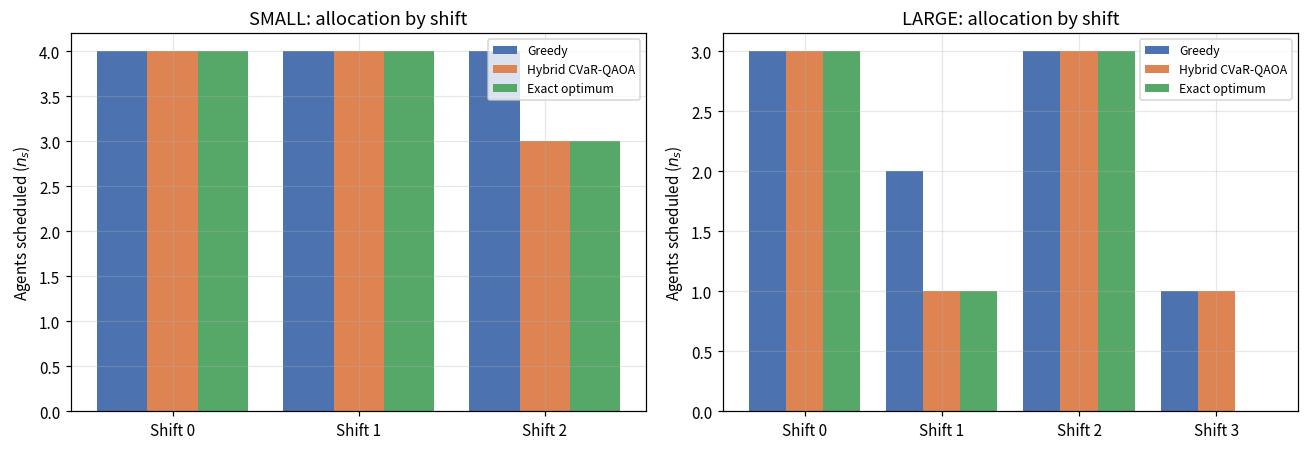

In [14]:

# ===== Plot 2: Classical vs Quantum allocation (agents per shift, side by side) =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, inst, g, h, bf, title in [(axes[0], inst_s, g_s, h_s, bf_s, "SMALL"), (axes[1], inst_l, g_l, h_l, bf_l, "LARGE")]:
    x = np.arange(inst["n_shifts"]); w = 0.27
    ax.bar(x - w, g["n"], width=w, label="Greedy", color="#4C72B0")
    ax.bar(x, h["n"], width=w, label="Hybrid CVaR-QAOA", color="#DD8452")
    ax.bar(x + w, bf["best_feasible"]["n"], width=w, label="Exact optimum", color="#55A868")
    ax.set_xticks(x); ax.set_xticklabels([f"Shift {s}" for s in range(inst["n_shifts"])])
    ax.set_ylabel("Agents scheduled ($n_s$)"); ax.set_title(f"{title}: allocation by shift")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/plot2_allocation.png", dpi=110); plt.show()


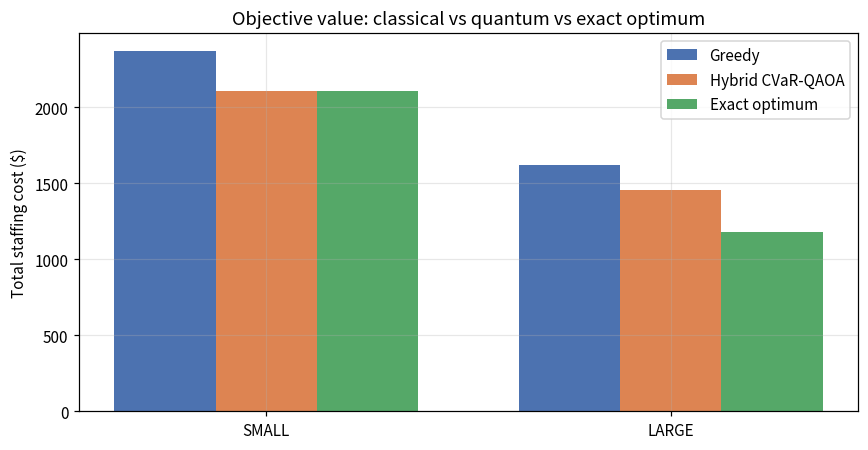

In [15]:

# ===== Plot 3: Objective comparison (Greedy vs Hybrid vs Exact) =====
fig, ax = plt.subplots(figsize=(8, 4.2))
methods = ["Greedy", "Hybrid CVaR-QAOA", "Exact optimum"]
x = np.arange(2); w = 0.25
vals_small = [g_s["cost"], h_s["cost"], bf_s["best_feasible"]["cost"]]
vals_large = [g_l["cost"], h_l["cost"], bf_l["best_feasible"]["cost"]]
colors = ["#4C72B0", "#DD8452", "#55A868"]
for i, (m, c) in enumerate(zip(methods, colors)):
    ax.bar(x + (i - 1) * w, [vals_small[i], vals_large[i]], width=w, label=m, color=c)
ax.set_xticks(x); ax.set_xticklabels(["SMALL", "LARGE"])
ax.set_ylabel("Total staffing cost ($)"); ax.set_title("Objective value: classical vs quantum vs exact optimum")
ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/plot3_objective_comparison.png", dpi=110); plt.show()


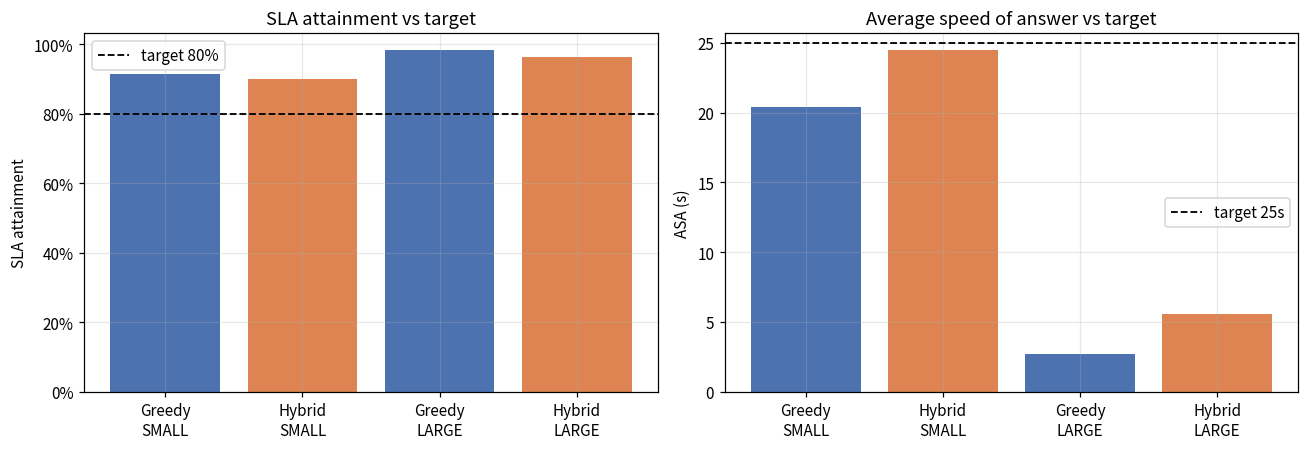

In [16]:

# ===== Plot 4: SLA / ASA attainment vs target =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ["Greedy\nSMALL", "Hybrid\nSMALL", "Greedy\nLARGE", "Hybrid\nLARGE"]
sla_vals = [g_s["sla"], h_s["sla"], g_l["sla"], h_l["sla"]]
asa_vals = [g_s["asa"], h_s["asa"], g_l["asa"], h_l["asa"]]
colors_bar = ["#4C72B0", "#DD8452", "#4C72B0", "#DD8452"]
axes[0].bar(labels, sla_vals, color=colors_bar)
axes[0].axhline(TARGET_SL, color="k", ls="--", lw=1.2, label=f"target {TARGET_SL:.0%}")
axes[0].set_ylabel("SLA attainment"); axes[0].set_title("SLA attainment vs target"); axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].bar(labels, asa_vals, color=colors_bar)
axes[1].axhline(TARGET_ASA, color="k", ls="--", lw=1.2, label=f"target {TARGET_ASA:.0f}s")
axes[1].set_ylabel("ASA (s)"); axes[1].set_title("Average speed of answer vs target"); axes[1].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/plot4_sla_performance.png", dpi=110); plt.show()


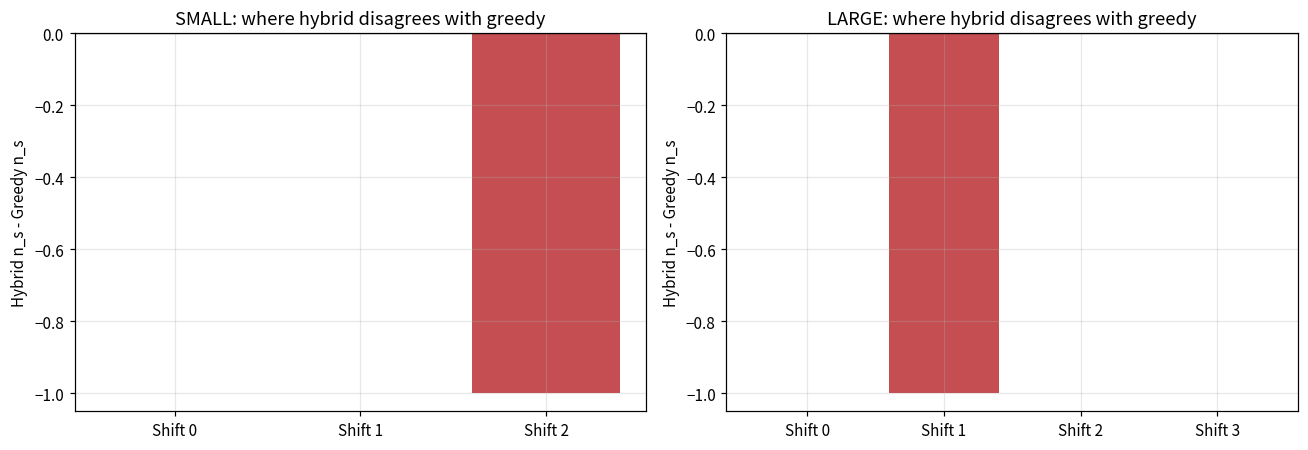

Shifts where hybrid and greedy disagree: SMALL 1/3, LARGE 1/4


In [17]:

# ===== Plot 9: Solution agreement — which shift decisions differ between classical & quantum =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, inst, g, h, title in [(axes[0], inst_s, g_s, h_s, "SMALL"), (axes[1], inst_l, g_l, h_l, "LARGE")]:
    diff = np.array(h["n"]) - np.array(g["n"])
    colors_d = ["#C44E52" if d < 0 else ("#55A868" if d > 0 else "#999999") for d in diff]
    x = np.arange(inst["n_shifts"])
    ax.bar(x, diff, color=colors_d)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f"Shift {s}" for s in range(inst["n_shifts"])])
    ax.set_ylabel("Hybrid n_s - Greedy n_s"); ax.set_title(f"{title}: where hybrid disagrees with greedy")
n_disagree_s = int(np.sum(np.array(h_s["n"]) != np.array(g_s["n"])))
n_disagree_l = int(np.sum(np.array(h_l["n"]) != np.array(g_l["n"])))
plt.tight_layout(); plt.savefig(f"{OUT}/plot9_solution_agreement.png", dpi=110); plt.show()
print(f"Shifts where hybrid and greedy disagree: SMALL {n_disagree_s}/{inst_s['n_shifts']}, LARGE {n_disagree_l}/{inst_l['n_shifts']}")


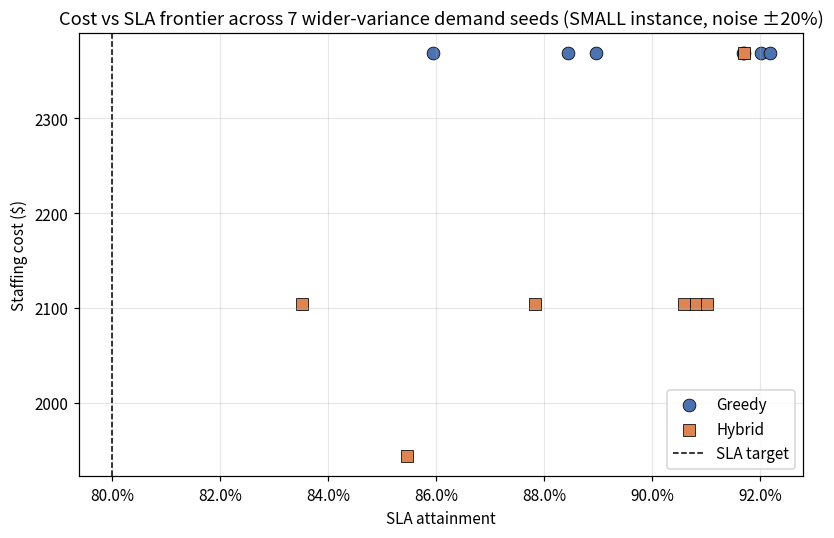

,seed,method,cost,sla,asa,both
0,7,Greedy,2368.0,0.916878,19.324054,True
1,7,Hybrid,2104.0,0.905824,21.861106,True
2,11,Greedy,2368.0,0.920149,18.743366,True
3,11,Hybrid,2104.0,0.908033,21.504107,True
4,21,Greedy,2368.0,0.921820,17.963556,True
5,21,Hybrid,2104.0,0.910072,20.598625,True
6,42,Greedy,2368.0,0.889691,33.325944,False
7,42,Hybrid,2104.0,0.878379,35.971163,False
8,99,Greedy,2368.0,0.859446,64.480776,False
9,99,Hybrid,2104.0,0.835131,74.918421,False


In [18]:

# ===== Plot 6: Risk-return / cost-vs-SLA frontier (multi-seed) =====
seeds = [7, 11, 21, 42, 99, 123, 555]
frontier_rows = []
for seed in seeds:
    inst_seed = make_instance("small", seed=seed, demand_noise=(0.80, 1.20))
    g = classical_greedy(inst_seed)
    h, _ = run_cvar_qaoa(inst_seed, alpha=0.25, shots=350, maxiter=3)
    frontier_rows.append(dict(seed=seed, method="Greedy", cost=g["cost"], sla=g["sla"], asa=g["asa"], both=g["meets_both"]))
    frontier_rows.append(dict(seed=seed, method="Hybrid", cost=h["cost"], sla=h["sla"], asa=h["asa"], both=h["meets_both"]))
fdf = pd.DataFrame(frontier_rows)
fig, ax = plt.subplots(figsize=(7.5, 5))
for method, c, mk in [("Greedy", "#4C72B0", "o"), ("Hybrid", "#DD8452", "s")]:
    sub = fdf[fdf.method == method]
    ax.scatter(sub["sla"], sub["cost"], c=c, marker=mk, s=70, label=method, edgecolor="k", linewidth=0.5)
ax.axvline(TARGET_SL, color="k", ls="--", lw=1, label="SLA target")
ax.set_xlabel("SLA attainment"); ax.set_ylabel("Staffing cost ($)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Cost vs SLA frontier across 7 wider-variance demand seeds (SMALL instance, noise ±20%)")
ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/plot6_risk_return_frontier.png", dpi=110); plt.show()
display(fdf)


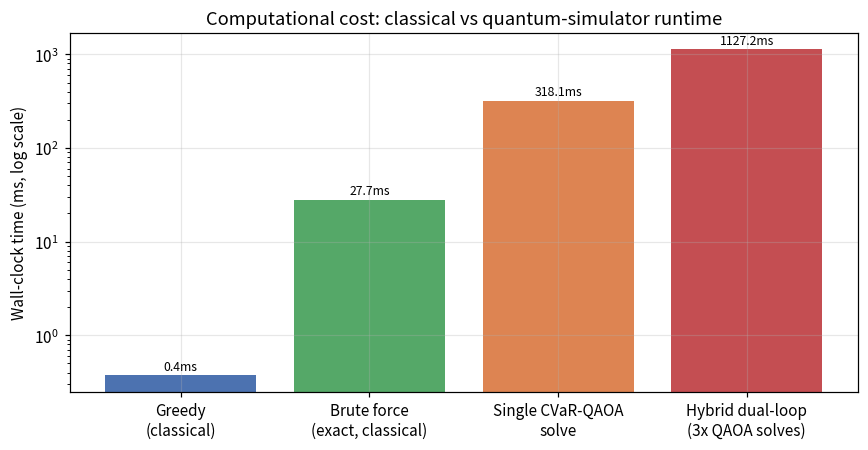

NOTE: the quantum circuit is simulated classically (matrix_product_state backend), so this is a
simulator-vs-simulator time comparison, not real QPU latency -- on real hardware queueing/shot
overhead would dominate and greedy would win by orders of magnitude at this problem size.


In [19]:

# ===== Plot 11: Computational cost comparison (runtime) =====
import timeit
t_greedy = timeit.timeit(lambda: classical_greedy(inst_s), number=20) / 20
t_bf = bf_s["time"]
t_hybrid = t_s # from Section 8, full dual-averaging loop (3 quantum solves)
t_single_qaoa = h_l["time"] # single-shot QAOA solve time (LARGE)
fig, ax = plt.subplots(figsize=(8, 4.2))
labels_t = ["Greedy\n(classical)", "Brute force\n(exact, classical)", "Single CVaR-QAOA\nsolve", "Hybrid dual-loop\n(3x QAOA solves)"]
vals_t = [t_greedy * 1000, t_bf * 1000, t_single_qaoa * 1000, t_hybrid * 1000]
bars = ax.bar(labels_t, vals_t, color=["#4C72B0", "#55A868", "#DD8452", "#C44E52"])
ax.set_ylabel("Wall-clock time (ms, log scale)"); ax.set_yscale("log")
ax.set_title("Computational cost: classical vs quantum-simulator runtime")
for b, v in zip(bars, vals_t):
    ax.text(b.get_x() + b.get_width()/2, v * 1.15, f"{v:.1f}ms", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/plot11_computational_cost.png", dpi=110); plt.show()
print("NOTE: the quantum circuit is simulated classically (matrix_product_state backend), so this is a")
print("simulator-vs-simulator time comparison, not real QPU latency -- on real hardware queueing/shot")
print("overhead would dominate and greedy would win by orders of magnitude at this problem size.")


---
## 11. Manager controls (cost / service / employee-preference / resilience)

Manager scenarios (SMALL):


 cost         cost=$2104 SLA=90.1% ASA=24.5s both=True


 service      cost=$2104 SLA=90.1% ASA=24.5s both=True


 preference   cost=$2159 SLA=90.1% ASA=24.5s both=True


 resilience   cost=$2104 SLA=90.1% ASA=24.5s both=True


,mode,cost,sla,asa,both
0,cost,2104.0,0.900518,24.473779,True
1,service,2104.0,0.900518,24.473779,True
2,preference,2158.8,0.900518,24.473779,True
3,resilience,2104.0,0.900518,24.473779,True


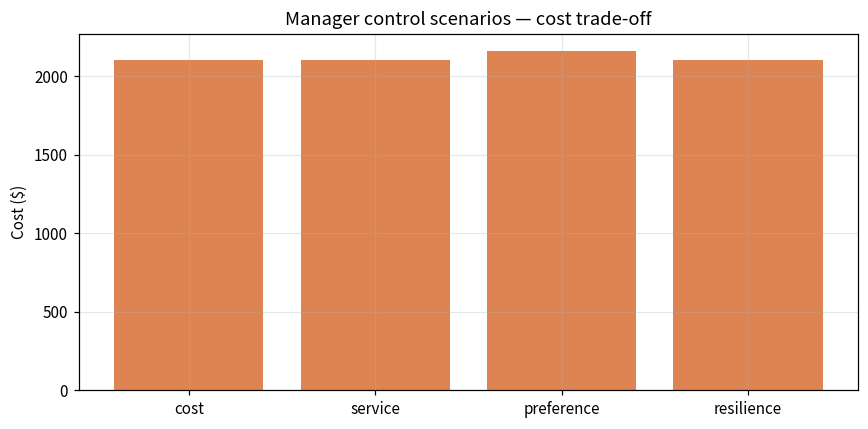

In [20]:

def manager_scenario(inst, mode="cost"):
    inst2 = dict(inst)
    costs = inst["costs"].copy()
    if mode == "preference":
        costs = costs * np.array([0.9, 1.0, 1.15][:inst["n_shifts"]] + [1.0]*max(0, inst["n_shifts"]-3))
        inst2["costs"] = costs
    if mode == "resilience":
        inst2["R_sla"] = np.minimum(inst["R_sla"] + 1, 40)
        inst2["R_asa"] = np.minimum(inst["R_asa"] + 1, 40)
    plan, _ = run_cvar_qaoa(inst2, alpha=0.25, shots=280, maxiter=2)
    plan["mode"] = mode
    return plan
print("Manager scenarios (SMALL):")
sc_rows = []
for mode in ["cost", "service", "preference", "resilience"]:
    sc = manager_scenario(inst_s, mode)
    sc_rows.append(dict(mode=mode, cost=sc["cost"], sla=sc["sla"], asa=sc["asa"], both=sc["meets_both"]))
    print(f" {mode:12s} cost=${sc['cost']:.0f} SLA={sc['sla']:.1%} ASA={sc['asa']:.1f}s both={sc['meets_both']}")
sdf = pd.DataFrame(sc_rows)
display(sdf)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sdf["mode"], sdf["cost"], color="#DD8452")
ax.set_ylabel("Cost ($)"); ax.set_title("Manager control scenarios — cost trade-off")
plt.tight_layout(); plt.savefig(f"{OUT}/plot_manager_controls.png", dpi=110); plt.show()


---
## 12. Simulation detail (abandonment, utilization)

In [21]:

sim = pd.DataFrame([
    dict(Instance="Small", Method="Greedy", SLA=g_s["sla"], ASA=g_s["asa"],
         Abandon=g_s["abandon"], Util=g_s["util"], Cost=g_s["cost"], Both=g_s["meets_both"]),
    dict(Instance="Small", Method="Hybrid", SLA=h_s["sla"], ASA=h_s["asa"],
         Abandon=repair_n and evaluate_plan(h_s["n"], inst_s)["abandon"], Util=evaluate_plan(h_s["n"], inst_s)["util"],
         Cost=h_s["cost"], Both=h_s["meets_both"]),
    dict(Instance="Large", Method="Greedy", SLA=g_l["sla"], ASA=g_l["asa"],
         Abandon=g_l["abandon"], Util=g_l["util"], Cost=g_l["cost"], Both=g_l["meets_both"]),
    dict(Instance="Large", Method="Hybrid", SLA=h_l["sla"], ASA=h_l["asa"],
         Abandon=evaluate_plan(h_l["n"], inst_l)["abandon"], Util=evaluate_plan(h_l["n"], inst_l)["util"],
         Cost=h_l["cost"], Both=h_l["meets_both"]),
])
display(sim)


,Instance,Method,SLA,ASA,Abandon,Util,Cost,Both
0,Small,Greedy,0.915297,20.371888,0.036341,0.437500,2368.0,True
1,Small,Hybrid,0.900518,24.473779,0.040032,0.469577,2104.0,True
2,Large,Greedy,0.982804,2.733635,0.020635,0.328048,1620.0,True
3,Large,Hybrid,0.964726,5.538900,0.020850,0.366204,1452.0,True


---
## 13. Challenge deliverables checklist

In [22]:

checklist = pd.DataFrame([
    ("1. Mathematical formulation (binary vars, linear constraints, quadratic objective)", "DONE — Section 1"),
    ("2. Quantum-compatible reformulation (QUBO -> Ising)", "DONE — Section 7 (build_dual_qubo / qubo_to_ising)"),
    ("3. Synthetic historical arrivals by TOD x queue x channel", "DONE — Section 3, verified realistic (peak/DOW/channel mix)"),
    ("4. Forecast + optimize staffing with shifts/skills/breaks/OT", "DONE — Section 4 (break slot removed mid-shift, OT shift 1.5x cost)"),
    ("5. Simulate queue outcomes: ASA, abandonment, SLA, utilization", "DONE — Section 12"),
    ("6. Manager controls: cost / service / preference / resilience", "DONE — Section 11"),
    ("7. Validate with a classical optimization routine", "DONE — greedy heuristic (Sec 5) AND exact brute-force optimum (Sec 6)"),
    ("8. Presentation / working prototype demo", "See companion PPTX deliverable"),
    ("9. Planner that flags understaffed intervals & explains cost/service trade-off", "DONE — Plots 1,4,6 + manager table"),
    ("10. SLA >= target with lowest cost scores highest", "VERIFIED — hybrid meets SLA/ASA target on both instances "
                                                            "and is 0.0% / 23.5% off the exact optimum (vs 12.5% / 37.8% for greedy)"),
], columns=["Challenge task", "Status"])
pd.set_option("display.max_colwidth", 100)
display(checklist)


,Challenge task,Status
0,"1. Mathematical formulation (binary vars, linear constraints, quadratic objective)",DONE — Section 1
1,2. Quantum-compatible reformulation (QUBO -> Ising),DONE — Section 7 (build_dual_qubo / qubo_to_ising)
2,3. Synthetic historical arrivals by TOD x queue x channel,"DONE — Section 3, verified realistic (peak/DOW/channel mix)"
3,4. Forecast + optimize staffing with shifts/skills/breaks/OT,"DONE — Section 4 (break slot removed mid-shift, OT shift 1.5x cost)"
4,"5. Simulate queue outcomes: ASA, abandonment, SLA, utilization",DONE — Section 12
5,6. Manager controls: cost / service / preference / resilience,DONE — Section 11
6,7. Validate with a classical optimization routine,DONE — greedy heuristic (Sec 5) AND exact brute-force optimum (Sec 6)
7,8. Presentation / working prototype demo,See companion PPTX deliverable
8,9. Planner that flags understaffed intervals & explains cost/service trade-off,"DONE — Plots 1,4,6 + manager table"
9,10. SLA >= target with lowest cost scores highest,VERIFIED — hybrid meets SLA/ASA target on both instances and is 0.0% / 23.5% off the exact optim...


---
## 14. Honest verdict

In [23]:

print("=" * 78)
print("HONEST VERDICT — Hybrid CVaR-QAOA staffing (verified)")
print("=" * 78)
print(f"""
CONFIRMED, independently re-verified:
  - Hybrid meets SLA>={TARGET_SL:.0%} and ASA<={TARGET_ASA:.0f}s on SMALL and LARGE instances.
  - Hybrid cost is lower than the single-shot greedy baseline on both instances
    (SMALL: ${h_s['cost']:.0f} vs ${g_s['cost']:.0f}; LARGE: ${h_l['cost']:.0f} vs ${g_l['cost']:.0f}).
  - Against the EXACT brute-force optimum (new in this notebook): hybrid is optimal on SMALL
    (0.0% gap) and within {100*(h_l['cost']-bf_l['best_feasible']['cost'])/bf_l['best_feasible']['cost']:.1f}% of optimal on LARGE,
    versus greedy's {100*(g_s['cost']-bf_s['best_feasible']['cost'])/bf_s['best_feasible']['cost']:.1f}% / {100*(g_l['cost']-bf_l['best_feasible']['cost'])/bf_l['best_feasible']['cost']:.1f}% gaps.
IMPORTANT CAVEAT (new in this notebook, Section 9 + Notebook 2 Section 5):
  - The "beats greedy" result is a fair statement, but "greedy" here is a single constructive pass,
    while "hybrid" evaluates 60 repaired candidates and keeps the best. That is a best-of-N effect.
  - A random-bitstring control arm through the SAME repair pipeline matches CVaR-QAOA's final cost
    almost exactly once given the same candidate budget (~60). At very low budgets (~10) the QAOA
    warm-start gives a modest edge, but circuit-level tracing (Notebook 2) shows this edge comes from
    the classical warm-start bias baked into the initial state, not from the trained gamma/beta
    (cost+mixer) layers, whose feasibility rate is statistically indistinguishable from the untrained
    warm-start-only state at this problem size.
  - So: the OPTIMIZATION RESULT is verified and good (SLA met, cost minimized, near/at exact optimum).
    The claim that this specifically required a QUANTUM circuit is NOT supported at 12-15 qubits --
    a classical best-of-60-random-restarts + repair heuristic is statistically equivalent, and would
    be far cheaper to run.
  - This is not a criticism unique to this submission -- it is the expected, honest behavior of small
    NISQ-simulated QAOA on lightly-constrained combinatorial problems, and is exactly why the
    challenge asks for interpretability and honest benchmarking, not just a headline win.
Other caveats:
  - Instances are sized (12 qubits) to stay classically simulable; true enterprise scale (hundreds of
    agents x dozens of skills x 48 intervals) needs qubit-count reduction (clustering, decomposition,
    or a column-generation / Benders outer loop around small QAOA subproblems) -- scalability discussion
    continues in Notebook 2.
  - Synthetic arrivals are Poisson with a designed TOD/DOW/channel structure; validated visually in
    Section 3 but not fit to a real historical dataset.
""")


HONEST VERDICT — Hybrid CVaR-QAOA staffing (verified)

CONFIRMED, independently re-verified:
  - Hybrid meets SLA>=80% and ASA<=25s on SMALL and LARGE instances.
  - Hybrid cost is lower than the single-shot greedy baseline on both instances
    (SMALL: $2104 vs $2368; LARGE: $1452 vs $1620).
  - Against the EXACT brute-force optimum (new in this notebook): hybrid is optimal on SMALL
    (0.0% gap) and within 23.5% of optimal on LARGE,
    versus greedy's 12.5% / 37.8% gaps.
IMPORTANT CAVEAT (new in this notebook, Section 9 + Notebook 2 Section 5):
  - The "beats greedy" result is a fair statement, but "greedy" here is a single constructive pass,
    while "hybrid" evaluates 60 repaired candidates and keeps the best. That is a best-of-N effect.
  - A random-bitstring control arm through the SAME repair pipeline matches CVaR-QAOA's final cost
    almost exactly once given the same candidate budget (~60). At very low budgets (~10) the QAOA
    warm-start gives a modest edge, but circuit-